## load_linnerud

In [1]:
from sklearn import tree
from sklearn import datasets
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
data = datasets.load_linnerud()

In [3]:
print(data.keys())
for f in data.keys():
    t = type(data[f])
    print('key: {}, type: {}'.format(f, t))
    if t == np.ndarray:
        print('shape: {}'.format(data[f].shape))

dict_keys(['data', 'feature_names', 'target', 'target_names', 'frame', 'DESCR', 'data_filename', 'target_filename', 'data_module'])
key: data, type: <class 'numpy.ndarray'>
shape: (20, 3)
key: feature_names, type: <class 'list'>
key: target, type: <class 'numpy.ndarray'>
shape: (20, 3)
key: target_names, type: <class 'list'>
key: frame, type: <class 'NoneType'>
key: DESCR, type: <class 'str'>
key: data_filename, type: <class 'str'>
key: target_filename, type: <class 'str'>
key: data_module, type: <class 'str'>


In [4]:
print(data.feature_names)
print(data.target_names)

['Chins', 'Situps', 'Jumps']
['Weight', 'Waist', 'Pulse']


In [5]:
print(data.DESCR)

.. _linnerrud_dataset:

Linnerrud dataset
-----------------

**Data Set Characteristics:**

:Number of Instances: 20
:Number of Attributes: 3
:Missing Attribute Values: None

The Linnerud dataset is a multi-output regression dataset. It consists of three
exercise (data) and three physiological (target) variables collected from
twenty middle-aged men in a fitness club:

- *physiological* - CSV containing 20 observations on 3 physiological variables:
   Weight, Waist and Pulse.
- *exercise* - CSV containing 20 observations on 3 exercise variables:
   Chins, Situps and Jumps.

.. dropdown:: References

   * Tenenhaus, M. (1998). La regression PLS: theorie et pratique. Paris:
     Editions Technic.



In [6]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['Weight'] = data.target[:, 0]
df['Waist'] = data.target[:, 1]
df['Pulse'] = data.target[:, 2]

In [7]:
df.head()

,Chins,Situps,Jumps,Weight,Waist,Pulse
0,5.0,162.0,60.0,191.0,36.0,50.0
1,2.0,110.0,60.0,189.0,37.0,52.0
2,12.0,101.0,101.0,193.0,38.0,58.0
3,12.0,105.0,37.0,162.0,35.0,62.0
4,13.0,155.0,58.0,189.0,35.0,46.0


In [8]:
df_src = pd.DataFrame(data=data.data, columns=data.feature_names)
df_target = pd.DataFrame(data=data.target, columns=data.target_names)
df = pd.concat([df_src, df_target], axis=1)

In [9]:
df.head()

,Chins,Situps,Jumps,Weight,Waist,Pulse
0,5.0,162.0,60.0,191.0,36.0,50.0
1,2.0,110.0,60.0,189.0,37.0,52.0
2,12.0,101.0,101.0,193.0,38.0,58.0
3,12.0,105.0,37.0,162.0,35.0,62.0
4,13.0,155.0,58.0,189.0,35.0,46.0


In [10]:
df.tail()

,Chins,Situps,Jumps,Weight,Waist,Pulse
15,12.0,210.0,120.0,202.0,37.0,62.0
16,4.0,60.0,25.0,176.0,37.0,54.0
17,11.0,230.0,80.0,157.0,32.0,52.0
18,15.0,225.0,73.0,156.0,33.0,54.0
19,2.0,110.0,43.0,138.0,33.0,68.0


In [11]:
df.describe()

,Chins,Situps,Jumps,Weight,Waist,Pulse
count,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,9.450000,145.550000,70.30000,178.600000,35.400000,56.100000
std,5.286278,62.566575,51.27747,24.690505,3.201973,7.210373
min,1.000000,50.000000,25.00000,138.000000,31.000000,46.000000
25%,4.750000,101.000000,39.50000,160.750000,33.000000,51.500000
50%,11.500000,122.500000,54.00000,176.000000,35.000000,55.000000
75%,13.250000,210.000000,85.25000,191.500000,37.000000,60.500000
max,17.000000,251.000000,250.00000,247.000000,46.000000,74.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Chins   20 non-null     float64
 1   Situps  20 non-null     float64
 2   Jumps   20 non-null     float64
 3   Weight  20 non-null     float64
 4   Waist   20 non-null     float64
 5   Pulse   20 non-null     float64
dtypes: float64(6)
memory usage: 1.1 KB


In [13]:
print(df.isnull().sum())

Chins     0
Situps    0
Jumps     0
Weight    0
Waist     0
Pulse     0
dtype: int64


<Axes: >

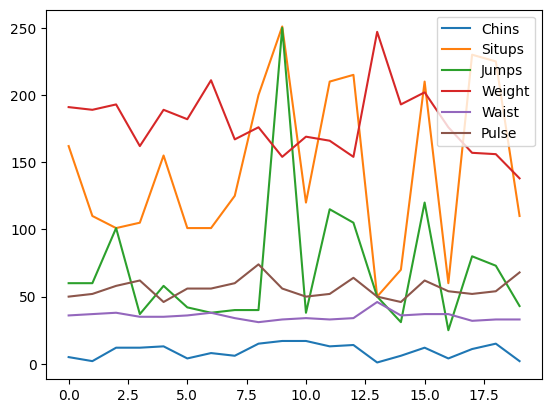

In [14]:
df.plot()

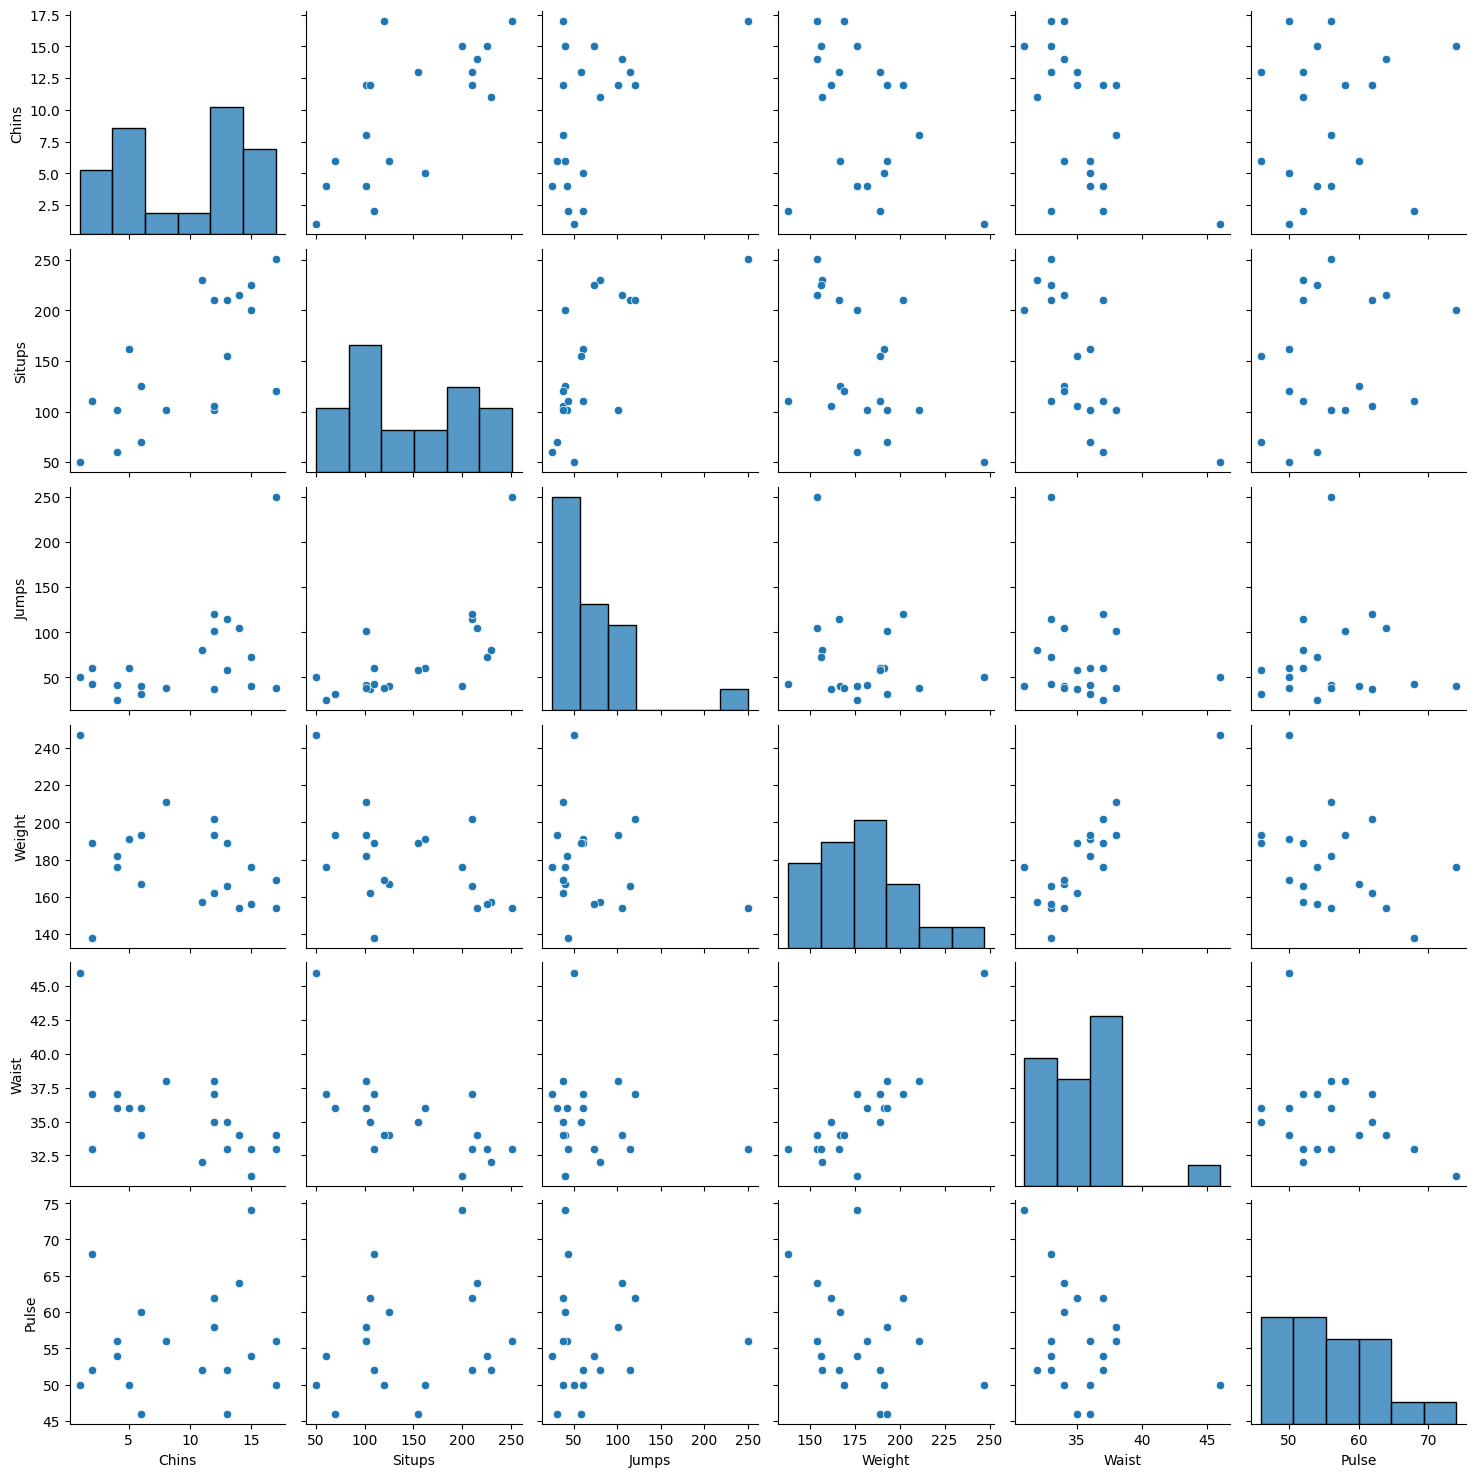

In [15]:
sns.pairplot(df)

In [16]:
X_train = data.data
y_train = data.target

In [17]:
model = tree.DecisionTreeRegressor()

In [18]:
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
y = model.predict(X_train)

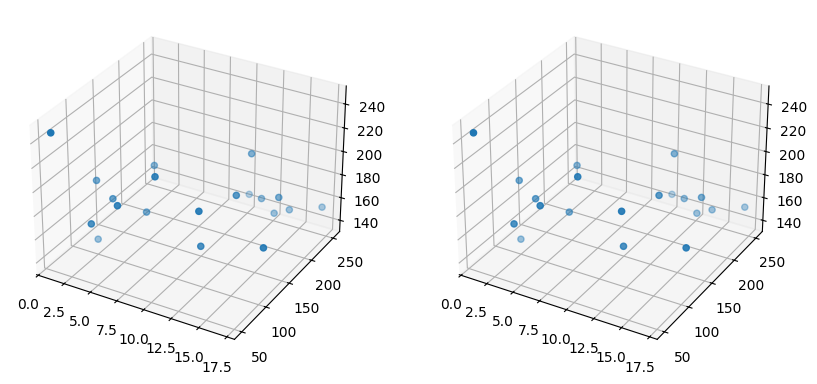

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig, axs = plt.subplots(ncols=2, figsize=(10, 5), subplot_kw={"projection":"3d"})
for ax, data in zip(axs, [y[:, 0], y_train[:, 0]]):
#    ax.scatter(X_train[:,0], X_train[:,1],X_train[:,2], c=data)
    ax.scatter(X_train[:,0], X_train[:,1], data)
plt.show()

In [21]:
print(model.score(X_train, y_train))

1.0


In [22]:
from sklearn.metrics import r2_score

#r2_score(y_train, y, multioutput='variance_weighted')
r2_score(y_train, y, multioutput='uniform_average')

1.0